# 02 — Composition cost calibration

Input: standard composition proposals (coach list, places per class, weight,
max speed, **material strategy: new-build vs. refurbished**) plus a reference
route. Output: paste-ready seed value blocks for `service_classes`,
`operators`, `operator_class_costs`, `coach_types`, `coach_type_classes`,
`composition_types`, `composition_type_coaches` — every value traceable to a
row in `data/parameter_observations.csv` and validated against the benchmark
corridors in `data/benchmark_observations.csv`.

Runs end-to-end from the CSVs written by `01_source_extraction.ipynb`. While
extraction is incomplete the calibration falls back to the S13 placeholder
priors, so the pipeline and the validation always work — quality improves as
observation rows land in 01.

**Scope:** operator-controllable costs only. Track access, station and OPS
infrastructure charges, and traction energy are excluded (separate
workstreams); energy regression factors are passed through unchanged from the
current seed.

**Formula mirror:** section 2 deliberately mirrors the cost formulas of
`models/evaluation/calc.py` / `CALC_FORMULAS` (operator-controllable subset)
so this notebook is self-contained. If the backend formulas change, update
the mirror. Three deliberate deviations, all flagged inline: driver/crew overhead
hours are applied here (backend TODO — loaded but not yet applied);
`coach_maint_eur_km` is treated as per **coach**-km here and emitted as
`rate × n_coaches` because `calc.py` applies the stored value per train-km;
and `fix_overhead_eur` is computed as a share of **all other operating
costs** (decision 2026-07-10) — this matches the documented DB semantics
(`operators` DDL comment: 'share of all other railway operation costs') but
not the current `calc.py` implementation (share of amortisation), which is
scheduled for a backend change with CALC_VERSION bump — see README.

**Sync 2026-07-20 (CALIBRATION.md restructure):** eleven standard compositions
(aggregate definition; per-coach split deferred to workbook import); per-metre
purchase model (145/53 k€/m, DD ×1.12); loco lease two-tier by material
(REF 161 / NEW 174, 2032); crew role split (attendant 69.67 + one train manager
83.15) with the documented staffing rule; EBIT 0.10; driver/crew overhead-h
parameters dropped (schema drop pending); catering stockings dropped;
reference route re-grounded in the BoT night train database (S41: 14.5 h trip,
15.5 loco-h). Seed emission and CALC_VERSION bump remain deferred — see the
"What feeds the database" section of CALIBRATION.md.

**Sync 2026-07-21 (price basis policy):** maintenance escalated to nominal 2032
(1.00 new / 1.30 refurbished); benchmarks 2032-normalized at 2%/yr; cleaning escalated to 364
(S01 assumed 2030-nominal, consistent with the loco derivation); stockings
exempt (below their class uncertainty).

**Redesign 2026-07-22 (real coach types):** the catalog is rebuilt on the
composition workbook (check.xlsx): eight compositions (REF-BUD/COUCH/BAL/
PREM families + NEW-BAL single/double formation), each an explicit ordered
list of **real coach types** with per-class sections (length/weight/crew per
section), service areas (dining car excluded via wo_service), the Zugchef
crew factor (1.19, doubled ≥10 coaches), n_locos, and the per-class cost
allocation model (X·length + (1−X)·weight on revenue space, service areas
per place; X=0.7). Capsule-only concepts (CAB/DD) are parked pending data.


## 1 — Setup

In [1]:
from dataclasses import dataclass, field
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


# Anchor data/ next to this notebook, independent of the kernel's working
# directory — PyCharm and Jupyter set different cwds, and a bare relative
# Path("data") breaks as soon as they disagree. Resolution order: cwd is
# the notebooks dir itself; cwd is data/; cwd is backend/ or the repo root.
def _resolve_data_dir() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / "02_calibration.ipynb").exists():
        return cwd / "data"
    if cwd.name == "data":
        return cwd
    for sub in (
        "models/compositions/notebooks/data",
        "backend/models/compositions/notebooks/data",
        "compositions/notebooks/data",
        "notebooks/data",
    ):
        if (cwd / sub).parent.is_dir():
            return cwd / sub
    return cwd / "data"


DATA_DIR = _resolve_data_dir()
DATA_DIR.mkdir(parents=True, exist_ok=True)
print(f"data directory: {DATA_DIR}")

_missing = [
    f
    for f in (
        "sources_register.csv",
        "parameter_observations.csv",
        "benchmark_observations.csv",
        "cost_bridge_mapping.csv",
        "coach_procurement_datapoints.csv",
    )
    if not (DATA_DIR / f).exists()
]
assert not _missing, (
    f"missing {_missing} in {DATA_DIR} — run 01_source_extraction.ipynb "
    "top to bottom first (it writes the observation CSVs there)"
)

parameter_obs = pd.read_csv(DATA_DIR / "parameter_observations.csv")
benchmark_obs = pd.read_csv(DATA_DIR / "benchmark_observations.csv")
bridge = pd.read_csv(DATA_DIR / "cost_bridge_mapping.csv")
procurement = pd.read_csv(DATA_DIR / "coach_procurement_datapoints.csv")
sources = pd.read_csv(DATA_DIR / "sources_register.csv")

parameter_obs

data directory: C:\Users\david\PycharmProjects\night-train-target-network-calib\backend\models\compositions\calib\data


,source_id,parameter,value,unit,condition,confidence,conversion_note,extraction_note
0,S13,driver_costs_eur_h,52.0,EUR/h,any,low,NaN,seed placeholder
1,S13,crew_costs_eur_h,38.0,EUR/h,any,low,NaN,seed placeholder
2,S13,driver_overhead_h,1.0,h/trip,any,low,NaN,seed placeholder
3,S13,crew_overhead_h,1.0,h/trip,any,low,NaN,seed placeholder
4,S13,loco_full_service_lease_eur_h,145.0,EUR/h,any,low,NaN,seed placeholder
5,S13,financing_quota_per,0.04,1/year,any,low,NaN,seed placeholder
6,S13,fix_overhead_quota_per,0.15,share of coach amortisation,any,low,NaN,seed placeholder
7,S13,var_overhead_per,0.1,share of revenue,any,low,NaN,seed placeholder
8,S13,ebit_margin_per,0.03,share of revenue,any,low,NaN,seed placeholder
9,S13,purchase_coach_eur,20000000.0,EUR/coach,any,low,NaN,seed placeholder — implausible; priority repla...


## 2 — Cost model driver layer (self-contained mirror)

Operator-controllable subset of the backend cost model. Annual cost per
composition on a reference route. Fleet sizing follows
`coach_amortisation_eur`'s definition: coaches required = coaches per train ×
trainsets, availability-adjusted.


In [2]:
from dataclasses import dataclass, field


@dataclass(frozen=True)
class S:
    """One class section inside a coach: places + its share of the coach's
    length/weight (basis of the class cost allocation) + crew factor."""

    class_main: str
    label: str  # section label -> DB class_id = "<coach> - <label>"
    places: int
    m: float
    t: float
    crew: float


@dataclass(frozen=True)
class C:
    """Real coach type. wo_service = full − servicing section (canonical
    rule; the workbook's excl_service columns carry a formula quirk for the
    NEW family). crew is the coach total incl. any service crew."""

    length_m: float
    weight_t: float
    svc_m: float
    svc_t: float
    crew: float
    wifi: bool
    bikes: bool
    aircon: bool
    plugs: bool
    sections: list

    @property
    def length_wo_svc(self):
        return self.length_m - self.svc_m

    @property
    def weight_wo_svc(self):
        return self.weight_t - self.svc_t


@dataclass(frozen=True)
class K:
    """Composition: ordered real-coach list + composition-level factors."""

    composition_type_id: str
    description: str
    material_strategy: str
    max_speed_kmh: float
    hsr_allowed: bool
    coaches: list  # ordered coach_type ids
    zugchef_crew_factor: float  # 1.19, doubled for >=10-coach formations
    n_locos: int
    length_cost_prop: float  # X in the class allocation (1-X on weight)
    fnb: str  # food & beverages concept (structured field later)

    @property
    def n_coaches(self):
        return len(self.coaches)

    def _cts(self):
        return [COACH_TYPES[c] for c in self.coaches]

    @property
    def length_m(self):
        return sum(c.length_m for c in self._cts())

    @property
    def weight_t(self):
        return sum(c.weight_t for c in self._cts())

    @property
    def length_wo_svc(self):
        return sum(c.length_wo_svc for c in self._cts())

    @property
    def weight_wo_svc(self):
        return sum(c.weight_wo_svc for c in self._cts())

    @property
    def total_crew(self):
        return sum(c.crew for c in self._cts()) + self.zugchef_crew_factor

    @property
    def places_by_class(self):
        out = {}
        for c in self._cts():
            for s in c.sections:
                out[s.class_main] = out.get(s.class_main, 0) + s.places
        return out

    @property
    def places(self):
        return sum(self.places_by_class.values())


@dataclass(frozen=True)
class ReferenceRoute:
    """S41-grounded: BoT Open Night Train Database sample."""

    length_km: float
    driving_h: float
    dwell_h: float
    loco_buffer_h: float
    operating_days: int
    trainsets: int

    @property
    def trip_h(self):
        return self.driving_h + self.dwell_h

    @property
    def loco_h(self):
        return self.trip_h + self.loco_buffer_h

    @property
    def trips_per_year(self):
        return self.trainsets * self.operating_days

    @property
    def train_km_per_year(self):
        return self.trips_per_year * self.length_km

In [3]:
@dataclass(frozen=True)
class CalibratedRates:
    driver_eur_h: float
    attendant_eur_h: float
    manager_eur_h: float  # one train manager per train
    loco_lease_eur_h: dict  # material -> EUR/h (REF 161 / NEW 174, 2032)
    financing_quota: float
    fix_overhead_quota: float  # share of all other operating costs
    var_overhead_quota: float  # revenue-side
    ebit_margin: float  # revenue-side
    purchase_rate_keur_m: dict  # material -> kEUR per metre
    dd_premium: float
    amort_years: dict
    coach_avail_per: dict
    cleaning_eur_coach_day: float
    maint_eur_coach_km: dict
    svc_stockings_eur_place: dict  # class -> EUR/place/trip (catering dropped)


# Decision record — every value documented in CALIBRATION.md (2026-07-20 state)
RATES = CalibratedRates(
    driver_eur_h=90.33,  # S17 2021 basis x wage chain to 2032
    attendant_eur_h=69.67,  # role split, x1.19 crew factor chain
    manager_eur_h=83.15,  # Zugchef base ratio-estimated (TO_VERIFY)
    loco_lease_eur_h={"refurbished": 161.0, "new": 174.0},  # 2032; NEW=230-config
    financing_quota=0.04,
    fix_overhead_quota=0.12,  # requires calc.py base change (pending)
    var_overhead_quota=0.08,
    ebit_margin=0.10,  # ES plan level (was 0.03)
    purchase_rate_keur_m={"new": 145.0, "refurbished": 53.0},
    dd_premium=1.12,
    amort_years={"new": 30, "refurbished": 12},
    coach_avail_per={"new": 0.909, "refurbished": 0.80},
    cleaning_eur_coach_day=364.0,  # 2032 (S01 assumed 2030-nominal, x1.02^2)
    maint_eur_coach_km={
        "new": 1.00,
        "refurbished": 1.30,
    },  # 2032 (price basis policy 2026-07-21)
    svc_stockings_eur_place={
        "seat": 0.25,
        "couchette": 0.60,
        "capsule": 1.00,
        "sleeper": 1.50,
    },
)


def purchase_total_eur(comp: K) -> float:
    """Per-metre purchase model on the full composition length (service
    coach included). dd_premium stays in RATES for future double-deck
    new-builds — none in the current catalog."""
    rate = RATES.purchase_rate_keur_m[comp.material_strategy] * 1000.0
    return rate * comp.length_m

In [4]:
def annual_cost_structure(comp: K, route: ReferenceRoute, rates: CalibratedRates):
    """Annual operator-controllable cost on real coach lists. Crew = coach
    crew factors + Zugchef, priced at the attendant rate; purchase via the
    per-metre model on the FULL composition length (service coach included
    — the dining car is bought, maintained and cleaned like any coach);
    loco costs scale with n_locos."""
    cond = comp.material_strategy
    trips = route.trips_per_year
    purch = (
        rates.purchase_rate_keur_m[cond]
        * 1000.0
        * comp.length_m
        * route.trainsets
        / rates.coach_avail_per[cond]
    )
    n_fleet = comp.n_coaches * route.trainsets / rates.coach_avail_per[cond]
    costs = {
        "driver_eur": rates.driver_eur_h * route.trip_h * trips,
        "crew_eur": comp.total_crew * rates.attendant_eur_h * route.trip_h * trips,
        "loco_eur": comp.n_locos * rates.loco_lease_eur_h[cond] * route.loco_h * trips,
        "coach_maintenance_eur": rates.maint_eur_coach_km[cond]
        * comp.n_coaches
        * route.train_km_per_year,
        "cleaning_eur": rates.cleaning_eur_coach_day * n_fleet * route.operating_days,
        "coach_amortisation_eur": purch / rates.amort_years[cond],
        "financing_eur": purch * rates.financing_quota,
        "svc_stockings_eur": sum(
            rates.svc_stockings_eur_place[cls] * pl
            for cls, pl in comp.places_by_class.items()
        )
        * trips,
    }
    costs["fix_overhead_eur"] = sum(costs.values()) * rates.fix_overhead_quota
    costs["total_eur"] = sum(v for k, v in costs.items() if k != "total_eur")
    return costs, n_fleet


def class_cost_allocation(comp: K) -> dict:
    """Per-class cost shares (the workbook mechanism, two steps):
    (1) revenue-space shares: X·(section length / length_wo_service)
        + (1−X)·(section weight / weight_wo_service);
    (2) the service-area cost fraction (same X-blend of the servicing
        share of length/weight) is allocated PER PLACE — every passenger
        pays equally for shared areas regardless of class."""
    X = comp.length_cost_prop
    frac_svc = (
        X * (comp.length_m - comp.length_wo_svc) / comp.length_m
        + (1 - X) * (comp.weight_t - comp.weight_wo_svc) / comp.weight_t
    )
    raw = {}
    for cls, pl in comp.places_by_class.items():
        lm = sum(s.m for c in comp._cts() for s in c.sections if s.class_main == cls)
        tm = sum(s.t for c in comp._cts() for s in c.sections if s.class_main == cls)
        raw[cls] = X * lm / comp.length_wo_svc + (1 - X) * tm / comp.weight_wo_svc
    # normalise the space shares: workbook section weights do not sum
    # exactly to coach weights for the NEW family (excl_service quirk),
    # so raw shares can sum slightly above 1 — shares must sum to 1
    total = sum(raw.values())
    shares = {}
    for cls, pl in comp.places_by_class.items():
        space = raw[cls] / total
        shares[cls] = round((1 - frac_svc) * space + frac_svc * pl / comp.places, 5)
    return shares


def cost_vs_mileage(comp, route, rates, annual_km):
    c, _ = annual_cost_structure(comp, route, rates)
    base_km = route.train_km_per_year / route.trainsets
    cap = (c["coach_amortisation_eur"] + c["financing_eur"]) / route.train_km_per_year
    var = (
        c["total_eur"] / route.train_km_per_year / (1 + rates.fix_overhead_quota) - cap
    )
    return (var + cap * base_km / annual_km) * (1 + rates.fix_overhead_quota)

## 3 — Standard composition proposals

Four archetypes derived from real fleet patterns, each with a **material
strategy** — this is where new-build vs. reused stock enters the model, via
four condition-dependent rates: purchase cost, amortisation period (full life
vs. remaining life), availability (old stock breaks more), and per-coach-km
maintenance (old stock costs more to maintain).

Capacity and weight figures are structural proposals to be verified during
extraction (patterns: European Sleeper / Snälltåget for refurbished
loco-hauled, Nightjet new generation for new-build — verify against
S03/S05/S10). All are marked in the remarks.


In [5]:
COACH_TYPES = {
    "A10tuh": C(
        26.4,
        54.48,
        0.0,
        0.0,
        0.0,
        False,
        False,
        True,
        True,
        [S("seat", "1st class  - seat (large room)", 56, 26.4, 54.48, 0.0)],
    ),
    "A9c9ux": C(
        26.4,
        52.88,
        0.0,
        0.0,
        0.5,
        True,
        False,
        True,
        True,
        [S("couchette", "couchette (4-berth)", 36, 26.4, 52.88, 0.5)],
    ),
    "ABbmpvz": C(
        26.5,
        45.5,
        0.0,
        0.0,
        0.0,
        True,
        True,
        True,
        True,
        [
            S("seat", "2nd class - seat (large room)", 26, 13.25, 24.83, 0.0),
            S("couchette", "couchette (4-berth) PRM", 4, 13.25, 23.07, 0.0),
        ],
    ),
    "ARkimmbz": C(26.4, 50.0, 26.4, 50.0, 2.0, False, False, True, False, []),
    "Am": C(
        26.4,
        55.28,
        0.0,
        0.0,
        0.0,
        False,
        False,
        True,
        False,
        [S("seat", "2nd class - compartments", 66, 26.4, 55.28, 0.0)],
    ),
    "Apm": C(
        26.4,
        54.8,
        0.0,
        0.0,
        0.0,
        False,
        False,
        True,
        True,
        [S("seat", "1st class  - seat (large room)", 60, 26.4, 54.8, 0.0)],
    ),
    "B (78)": C(
        26.4,
        56.24,
        0.0,
        0.0,
        0.0,
        False,
        False,
        True,
        True,
        [S("seat", "2nd class - seat (large room)", 78, 26.4, 56.24, 0.0)],
    ),
    "B10c10ux": C(
        26.4,
        54.8,
        0.0,
        0.0,
        0.5,
        True,
        False,
        True,
        True,
        [S("couchette", "couchette (6-berth)", 60, 26.4, 54.8, 0.5)],
    ),
    "B8c8ux": C(
        26.4,
        53.84,
        0.0,
        0.0,
        0.5,
        True,
        True,
        True,
        True,
        [S("couchette", "couchette (6-berth)", 48, 26.4, 53.84, 0.5)],
    ),
    "Bc (36)": C(
        26.4,
        52.88,
        0.0,
        0.0,
        0.5,
        False,
        False,
        True,
        False,
        [S("couchette", "couchette (4-berth)", 36, 26.4, 52.88, 0.5)],
    ),
    "Bcmz (54)": C(
        26.4,
        54.32,
        0.0,
        0.0,
        0.5,
        False,
        False,
        True,
        True,
        [S("couchette", "couchette (6-berth)", 54, 26.4, 54.32, 0.5)],
    ),
    "Bcmz_5291": C(
        26.5,
        45.5,
        0.0,
        0.0,
        0.5,
        True,
        False,
        True,
        True,
        [
            S("couchette", "couchette (4-berth)", 12, 7.949999999999999, 14.61, 0.15),
            S("capsule", "Mini-Cabin (bed)", 28, 18.549999999999997, 34.09, 0.35),
        ],
    ),
    "Bfmpz": C(
        26.8,
        46.0,
        0.0,
        0.0,
        0.0,
        True,
        False,
        True,
        True,
        [S("seat", "2nd class - seat (large room)", 70, 26.8, 55.6, 0.0)],
    ),
    "Bmpz (74)": C(
        26.4,
        55.92,
        0.0,
        0.0,
        0.0,
        False,
        False,
        True,
        True,
        [S("seat", "2nd class - seat (large room)", 74, 26.4, 55.92, 0.0)],
    ),
    "Bmz": C(
        26.4,
        55.28,
        0.0,
        0.0,
        0.0,
        False,
        False,
        True,
        True,
        [S("seat", "2nd class - compartments", 66, 26.4, 55.28, 0.0)],
    ),
    "Bpm (78)": C(
        26.4,
        56.24,
        0.0,
        0.0,
        0.0,
        False,
        True,
        True,
        True,
        [S("seat", "2nd class - seat (large room)", 78, 26.4, 56.24, 0.0)],
    ),
    "Bvcmbz": C(
        26.4,
        54.0,
        0.0,
        0.0,
        0.5,
        False,
        False,
        True,
        True,
        [
            S(
                "couchette",
                "48 * couchette (6-berth) + 2 couchette PRM (2-berth)",
                50,
                26.4,
                54.0,
                0.5,
            )
        ],
    ),
    "Bvcmz (50)": C(
        26.4,
        54.0,
        0.0,
        0.0,
        0.5,
        False,
        False,
        True,
        False,
        [S("couchette", "couchette (5-berth)", 50, 26.4, 54.0, 0.5)],
    ),
    "Bvcmz (60)": C(
        26.4,
        54.8,
        0.0,
        0.0,
        0.5,
        False,
        False,
        True,
        True,
        [S("couchette", "couchette (6-berth)", 60, 26.4, 54.8, 0.5)],
    ),
    "WLABee": C(
        26.4,
        52.4,
        0.0,
        0.0,
        0.0,
        False,
        False,
        True,
        False,
        [S("sleeper", "Sleeper (3-berth) with basin", 30, 26.4, 52.4, 0.0)],
    ),
    "WLABm (36)": C(
        26.4,
        52.88,
        0.0,
        0.0,
        1.0,
        False,
        False,
        True,
        False,
        [S("sleeper", "sleeper (unspecified)", 36, 26.4, 52.88, 1.0)],
    ),
    "WLABmz (DD)": C(
        26.4,
        62.4,
        0.0,
        0.0,
        1.0,
        False,
        False,
        True,
        True,
        [
            S(
                "sleeper",
                "18 * Sleeper (2-berth) with basin + 8 * Sleeper (2-berth) with shower & WC + 4 * Sleeper (4-berth) with basin",
                30,
                26.4,
                62.4,
                1.0,
            )
        ],
    ),
    "WLAmz_7091": C(
        26.45,
        45.5,
        0.0,
        0.0,
        1.0,
        True,
        False,
        True,
        True,
        [
            S(
                "sleeper",
                "18 * Sleeper (2-berth) with shower option & WC + 2 * Sleeper (2-berth) with shower & WC",
                20,
                26.45,
                47.1,
                1.0,
            )
        ],
    ),
    "WLBmz (DD)": C(
        26.4,
        63.36,
        0.0,
        0.0,
        1.0,
        False,
        False,
        True,
        True,
        [
            S(
                "sleeper",
                "34 * Sleeper (2-berth) with basin + 8 * Sleeper (4-berth) with basin",
                42,
                26.4,
                63.36,
                1.0,
            )
        ],
    ),
}

STANDARD_COMPOSITIONS = [
    K(
        "REF-BUD-6",
        "Small budget oriented formation (seats, couchettes) simliar to Snalltaget",
        "refurbished",
        200,
        False,
        [
            "Bmpz (74)",
            "Bvcmz (60)",
            "Bvcmz (60)",
            "Bmpz (74)",
            "Bvcmz (60)",
            "Bvcmz (60)",
        ],
        1.19,
        1,
        0.7,
        "kiosk/ trolley service/ morning service",
    ),
    K(
        "REF-COUCH-6",
        "Small couchette heavy formation simliar to Intercity Notte FS 6-coaches formation",
        "refurbished",
        200,
        False,
        ["Bc (36)", "Bc (36)", "Bc (36)", "Bc (36)", "Bc (36)", "WLABm (36)"],
        1.19,
        1,
        0.7,
        "kiosk/ trolley service/ morning service",
    ),
    K(
        "REF-BAL-9",
        "Balanced  formation with 9 coaches, similar to current SBB/ÖBB-operated consists",
        "refurbished",
        200,
        False,
        [
            "Bpm (78)",
            "Bpm (78)",
            "Bmz",
            "Bmz",
            "Apm",
            "Bcmz (54)",
            "Bvcmbz",
            "WLBmz (DD)",
            "WLABmz (DD)",
        ],
        1.19,
        1,
        0.7,
        "kiosk/ trolley service/ morning service",
    ),
    K(
        "REF-COUCH-10",
        "Couchette heavy 10 coach formation (similar to SNCF Intercity nuit)",
        "refurbished",
        200,
        False,
        [
            "A10tuh",
            "B8c8ux",
            "A9c9ux",
            "B10c10ux",
            "B10c10ux",
            "B10c10ux",
            "B10c10ux",
            "A9c9ux",
            "B10c10ux",
            "B10c10ux",
        ],
        2.38,
        1,
        0.7,
        "kiosk/ trolley service/ morning service",
    ),
    K(
        "REF-BUD-12",
        "Large seat and couchette mix simliar to Intercity Notte FS 12-coaches formation",
        "refurbished",
        200,
        False,
        [
            "B (78)",
            "B (78)",
            "B (78)",
            "B (78)",
            "Bc (36)",
            "Bc (36)",
            "Bc (36)",
            "Bc (36)",
            "Bc (36)",
            "WLABm (36)",
            "WLABm (36)",
            "WLABm (36)",
        ],
        2.38,
        1,
        0.7,
        "kiosk/ trolley service/ morning service",
    ),
    K(
        "REF-PREM-12",
        "Large couchette and sleeper mix simliar to European Sleeper operation",
        "refurbished",
        200,
        False,
        [
            "WLABee",
            "WLABee",
            "Bvcmz (50)",
            "Bvcmz (50)",
            "Bvcmz (50)",
            "Bvcmz (50)",
            "Bvcmz (50)",
            "Bvcmz (50)",
            "Bvcmz (50)",
            "Bvcmz (50)",
            "ARkimmbz",
            "Am",
        ],
        2.38,
        1,
        0.7,
        "dining car",
    ),
    K(
        "NEW-BAL-7",
        "Similar to OEBB nightjet next generation",
        "new",
        230,
        True,
        [
            "Bfmpz",
            "ABbmpvz",
            "Bcmz_5291",
            "Bcmz_5291",
            "Bcmz_5291",
            "WLAmz_7091",
            "WLAmz_7091",
        ],
        1.19,
        1,
        0.7,
        "kiosk/ trolley service/ morning service",
    ),
    K(
        "NEW-BAL-14",
        "Similar to OEBB nightjet next generation double formation",
        "new",
        230,
        True,
        [
            "Bfmpz",
            "ABbmpvz",
            "Bcmz_5291",
            "Bcmz_5291",
            "Bcmz_5291",
            "WLAmz_7091",
            "WLAmz_7091",
            "WLAmz_7091",
            "WLAmz_7091",
            "Bcmz_5291",
            "Bcmz_5291",
            "Bcmz_5291",
            "ABbmpvz",
            "Bfmpz",
        ],
        2.38,
        1,
        0.7,
        "kiosk/ trolley service/ morning service",
    ),
]
print(
    len(STANDARD_COMPOSITIONS),
    "compositions,",
    sum(k.places for k in STANDARD_COMPOSITIONS),
    "places,",
    len(COACH_TYPES),
    "real coach types",
)

8 compositions, 3570 places, 24 real coach types


## 4 — Reference route

Needed only to turn rates into comparable aggregates (€/train-km,
ct/place-km). Chosen close to the implied nox reference so level comparisons
are apples-to-apples: one round trip per night, two trainsets in circulation.
Sensitivity of the corridor check to these choices is shown in section 7.


In [6]:
ROUTE = ReferenceRoute(
    length_km=1000.0,
    driving_h=13.5,  # S41: typical ~1,000 km at ~63-87 km/h -> 14.5 h trip
    dwell_h=1.0,
    loco_buffer_h=1.0,  # -> 15.5 loco-h
    operating_days=350,
    trainsets=2,
)
print(
    f"trip {ROUTE.trip_h} h, loco {ROUTE.loco_h} h, "
    f"trips/yr {ROUTE.trips_per_year}, train-km/yr {ROUTE.train_km_per_year:,.0f}"
)

trip 14.5 h, loco 15.5 h, trips/yr 700, train-km/yr 700,000


## 5 — Rate calibration

`CHOSEN` is the single decision record: per parameter one value, its source,
and a one-line rationale. Initially everything points at the S13 priors;
replacing a value means pointing at a different observation row from 01 and
writing the rationale. The purchase-price fit below overrides the flat prior
as soon as verified procurement datapoints exist.


In [7]:
# Superseded 2026-07-20: the per-class prior + rescale approach is replaced
# by the per-metre regression model (145 kEUR/m new [75-210], 53 refurb [17-],
# DD x1.12) anchored on five contract observations — see CALIBRATION.md,
# Coach purchase cost. The S06 per-class spread (WL 3.8 / Bc 2.8 / B 2.0 MEUR)
# is documented there as the sourced basis IF class factors are reintroduced.
print("purchase model: per-metre — see purchase_total_eur()")

purchase model: per-metre — see purchase_total_eur()


## 6 — Cost structure per standard composition

Per-year, per-trip, per-train-km and per-place-km, plus category shares —
the differentiated output the tool's evaluation pipeline expects.


In [8]:
results = {}
for comp in STANDARD_COMPOSITIONS:
    costs, n_fleet = annual_cost_structure(comp, ROUTE, RATES)
    tkm = ROUTE.train_km_per_year
    results[comp.composition_type_id] = {
        "costs": costs,
        "n_fleet": n_fleet,
        "per_train_km": {k: v / tkm for k, v in costs.items()},
        "ct_per_place_km": 100 * costs["total_eur"] / tkm / comp.places,
        "class_alloc": class_cost_allocation(comp),
    }
print({cid: round(r["per_train_km"]["total_eur"], 2) for cid, r in results.items()})

{'REF-BUD-6': 24.01, 'REF-COUCH-6': 25.69, 'REF-BAL-9': 33.19, 'REF-COUCH-10': 38.94, 'REF-BUD-12': 45.44, 'REF-PREM-12': 46.0, 'NEW-BAL-7': 27.94, 'NEW-BAL-14': 51.39}


In [9]:
per_tkm = pd.DataFrame({cid: r["per_train_km"] for cid, r in results.items()}).round(2)
alloc_df = (
    pd.DataFrame({cid: r["class_alloc"] for cid, r in results.items()})
    .fillna(0)
    .round(4)
)
print(alloc_df)
per_tkm

ct_place = pd.Series(
    {cid: r["ct_per_place_km"] for cid, r in results.items()}, name="ct/place-km"
).round(2)
ct_place

           REF-BUD-6  REF-COUCH-6  REF-BAL-9  REF-COUCH-10  REF-BUD-12  \
seat          0.3347       0.0000     0.5517        0.1001      0.3375   
couchette     0.6653       0.8333     0.2190        0.8999      0.4141   
sleeper       0.0000       0.1667     0.2292        0.0000      0.2484   
capsule       0.0000       0.0000     0.0000        0.0000      0.0000   

           REF-PREM-12  NEW-BAL-7  NEW-BAL-14  
seat            0.0944     0.2214      0.2214  
couchette       0.7306     0.1981      0.1981  
sleeper         0.1750     0.2814      0.2814  
capsule         0.0000     0.2990      0.2990  


REF-BUD-6        6.19
REF-COUCH-6     11.89
REF-BAL-9        6.33
REF-COUCH-10     7.27
REF-BUD-12       7.57
REF-PREM-12      8.75
NEW-BAL-7       10.75
NEW-BAL-14       9.88
Name: ct/place-km, dtype: float64

## 7 — Validation against benchmark corridors

Operator-controllable subtotal and per-category comparison against the
bridged benchmark observations (±30% acceptance band, as in the workstream
README). The UIC composition spread (seat-only < mixed < premium) must be
reproduced in ordering even where levels are not directly comparable.

**Decision status (2026-07-10):** `fix_overhead` now runs on the
all-other-operating-costs base (quota 0.12, nox-2036-derived) — backend
change specified in the README. Maintenance runs at the BVWP rate
(3.25 EUR/coach-km) per project decision; rolling stock is therefore
validated as one merged corridor (capital + maintenance vs nox 210 + 219),
since nox's lease bundles revisions our model carries in maintenance.
**Expected REVIEW flags:** rolling stock exceeds the merged corridor
~2.5-3.3x, driving totals to 40-53 EUR/tkm and 10-26 ct/place-km against
total corridors of 5.3-8.0 ct/place-km (each *including* infra+energy).
Resolution path per README: verify 3.25 against the primary BVWP 2016
Methodikhandbuch; if confirmed, adopt a documented middle value with
explicit revision-provisioning logic.


In [10]:
# Benchmarks (operator-only, 2032-normalized) — CALIBRATION.md
S01_CORRIDOR = (25.3, 26.8)
S06_HALFTRAIN = (43.8, 165_000)
S07_NELLDAL_OP = 24.6

rows = []
for comp in STANDARD_COMPOSITIONS:
    cid = comp.composition_type_id
    total = results[cid]["per_train_km"]["total_eur"]
    rows.append(
        {
            "composition": cid,
            "eur_tkm": round(total, 2),
            "ct_place_km": round(results[cid]["ct_per_place_km"], 2),
            "vs_S01_corridor": "in/below"
            if total <= S01_CORRIDOR[1]
            else f"+{total / S01_CORRIDOR[1] - 1:.0%}",
            "at_S06_mileage": round(
                cost_vs_mileage(comp, ROUTE, RATES, S06_HALFTRAIN[1]), 1
            ),
        }
    )
validation = pd.DataFrame(rows)
validation

,composition,eur_tkm,ct_place_km,vs_S01_corridor,at_S06_mileage
0,REF-BUD-6,24.01,6.19,in/below,28.7
1,REF-COUCH-6,25.69,11.89,in/below,30.3
2,REF-BAL-9,33.19,6.33,+24%,40.2
3,REF-COUCH-10,38.94,7.27,+45%,46.7
4,REF-BUD-12,45.44,7.57,+70%,54.7
5,REF-PREM-12,46.00,8.75,+72%,55.3
6,NEW-BAL-7,27.94,10.75,+4%,35.7
7,NEW-BAL-14,51.39,9.88,+92%,67.0


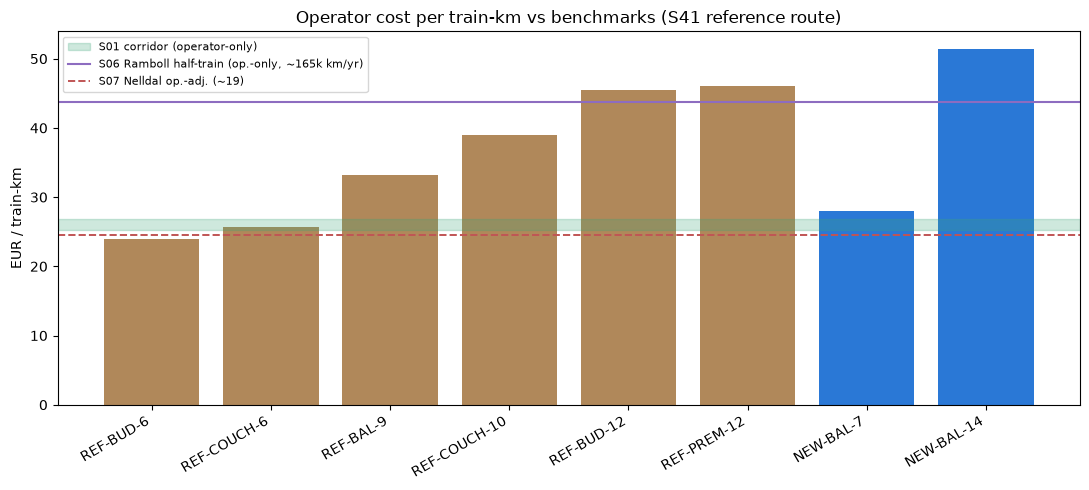

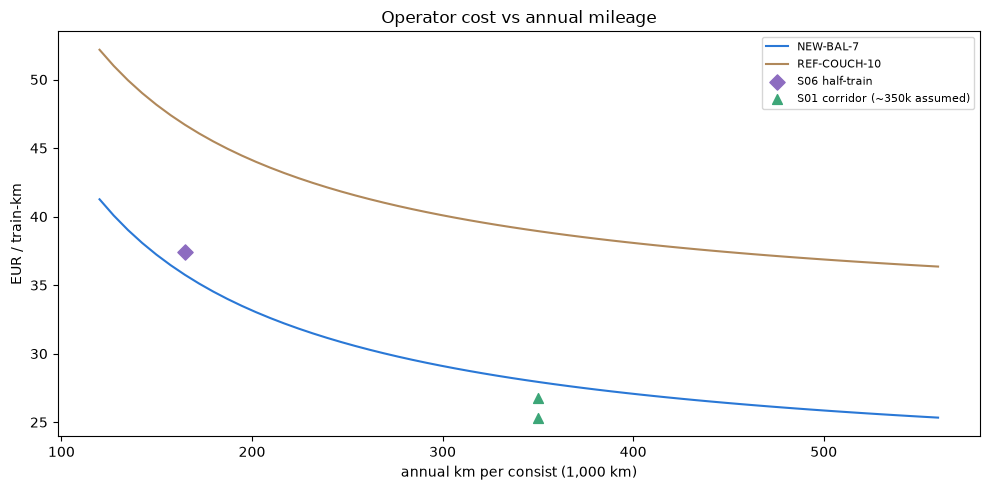

In [11]:
# Figure regeneration — updated to the new validation structure.
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 5))
v = validation.set_index("composition")
colors = ["#b0885a" if c.startswith("REF") else "#2a78d6" for c in v.index]
ax.bar(v.index, v["eur_tkm"], color=colors)
ax.axhspan(
    S01_CORRIDOR[0],
    S01_CORRIDOR[1],
    color="#3da678",
    alpha=0.25,
    label="S01 corridor (operator-only)",
)
ax.axhline(
    S06_HALFTRAIN[0],
    color="#8d6cc0",
    lw=1.5,
    label="S06 Ramboll half-train (op.-only, ~165k km/yr)",
)
ax.axhline(
    S07_NELLDAL_OP, color="#c05555", ls="--", lw=1.4, label="S07 Nelldal op.-adj. (~19)"
)
ax.set_ylabel("EUR / train-km")
ax.legend(fontsize=8)
ax.set_title("Operator cost per train-km vs benchmarks (S41 reference route)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("figures/cost_per_train_km_vs_benchmarks.png", dpi=150)

# Mileage curves figure (Benchmark reconciliation)
import numpy as np

fig2, ax2 = plt.subplots(figsize=(10, 5))
kms = np.linspace(120_000, 560_000, 60)
for comp, col in [
    (STANDARD_COMPOSITIONS[6], "#2a78d6"),
    (STANDARD_COMPOSITIONS[3], "#b0885a"),
]:
    ax2.plot(
        kms / 1000,
        [cost_vs_mileage(comp, ROUTE, RATES, k) for k in kms],
        color=col,
        label=comp.composition_type_id,
    )
ax2.scatter(
    [165], [37.4], marker="D", s=60, color="#8d6cc0", zorder=5, label="S06 half-train"
)
ax2.scatter(
    [350, 350],
    [S01_CORRIDOR[0], S01_CORRIDOR[1]],
    marker="^",
    s=50,
    color="#3da678",
    zorder=5,
    label="S01 corridor (~350k assumed)",
)
ax2.set_xlabel("annual km per consist (1,000 km)")
ax2.set_ylabel("EUR / train-km")
ax2.set_title("Operator cost vs annual mileage")
ax2.legend(fontsize=8)
plt.tight_layout()
plt.savefig("figures/cost_vs_annual_mileage.png", dpi=150)

## 8 — Seed emission

Paste-ready blocks for `backend/db/dev/seed.py`. Column names match the
current schema exactly; no schema change. Notes:

- `composition_type_purchase_coach_eur` = fleet-weighted average across the
  composition's coach list (schema holds one value per composition).
- `composition_type_coach_maint_eur_km` = per-coach-km rate × n_coaches,
  because `calc.py` applies the stored value per train-km (unit audit,
  section header).
- Energy factors and boarding/alighting times are passed through unchanged
  from the current seed (separate workstreams).
- The current seed's shared `STD_COMP_DEFAULTS` no longer fits — values now
  differ per composition. The emitted block is one full dict per composition
  type; `seed.py` should replace `STD_COMP_DEFAULTS`/
  `COMPOSITION_TYPES_VARYING` with these.


In [12]:
# ============================================================
# SEED EXPORT — calib/seed/*.csv, read by db/dev/seed.py.
# STDLIB-ONLY on purpose: db/dev/seed.py executes the pandas/matplotlib-
# free cells of this notebook as a fallback when the CSVs are absent
# (they are derived artifacts and not committed) — the API container has
# no dev extras, so this cell must not import pandas.
# Real coach types (workbook design 2026-07-22); class_id naming rule:
# "<coach_type_id> - <section label>".
# ============================================================
import csv as _csv
from pathlib import Path

SEED_DIR = Path("seed")
SEED_DIR.mkdir(exist_ok=True)


def _write_csv(name, fieldnames, rows):
    with open(SEED_DIR / name, "w", newline="") as f:
        w = _csv.DictWriter(f, fieldnames=fieldnames)
        w.writeheader()
        for r in rows:
            w.writerow(r)


_write_csv(
    "operators.csv",
    [
        "operator_id",
        "operator_name",
        "operator_driver_costs_eur_h",
        "operator_crew_costs_eur_h",
        "operator_ebit_margin_per",
        "operator_financing_quota_per",
        "operator_var_overhead_per",
        "operator_fix_overhead_quota_per",
        "operator_loco_lease_eur_h",
    ],
    [
        {
            "operator_id": f"STD-{tag}",
            "operator_name": f"Calibrated standard operator ({mat} fleet)",
            "operator_driver_costs_eur_h": RATES.driver_eur_h,
            "operator_crew_costs_eur_h": RATES.attendant_eur_h,
            "operator_ebit_margin_per": RATES.ebit_margin,
            "operator_financing_quota_per": RATES.financing_quota,
            "operator_var_overhead_per": RATES.var_overhead_quota,
            "operator_fix_overhead_quota_per": RATES.fix_overhead_quota,
            "operator_loco_lease_eur_h": RATES.loco_lease_eur_h[mat],
        }
        for tag, mat in (("REF", "refurbished"), ("NEW", "new"))
    ],
)

_write_csv(
    "operator_class_costs.csv",
    ["operator_id", "class_main", "svc_stockings_eur_place"],
    [
        {"operator_id": op, "class_main": cls, "svc_stockings_eur_place": rate}
        for op in ("STD-REF", "STD-NEW")
        for cls, rate in RATES.svc_stockings_eur_place.items()
    ],
)

fam = {}
for k in STANDARD_COMPOSITIONS:
    op = "STD-NEW" if k.material_strategy == "new" else "STD-REF"
    for ct in k.coaches:
        fam.setdefault(ct, set()).add(op)
coach_rows, class_rows = [], []
for ct in sorted(fam):
    assert len(fam[ct]) == 1, f"{ct} used across material families"
    c = COACH_TYPES[ct]
    coach_rows.append(
        {
            "coach_type_id": ct,
            "coach_type_operator_id": next(iter(fam[ct])),
            "coach_type_weight_gross_t": c.weight_t,
            "coach_type_length_m": c.length_m,
            "coach_type_weight_wo_service_t": round(c.weight_wo_svc, 2),
            "coach_type_length_wo_service_m": round(c.length_wo_svc, 2),
            "coach_type_crew_factor": c.crew,
            "coach_type_has_wifi": c.wifi,
            "coach_type_bikes": c.bikes,
            "coach_type_climatization": c.aircon,
            "coach_type_plugs": c.plugs,
            "coach_type_remarks": "Real coach type (composition workbook 2026-07-22)",
        }
    )
    for s in c.sections:
        class_rows.append(
            {
                "coach_type_id": ct,
                "class_id": f"{ct} - {s.label}",
                "class_main": s.class_main,
                "places": s.places,
                "section_length_m": s.m,
                "section_weight_t": round(s.t, 3),
                "section_crew_factor": s.crew,
            }
        )
_write_csv("coach_types.csv", list(coach_rows[0]), coach_rows)
_write_csv("coach_type_classes.csv", list(class_rows[0]), class_rows)

comp_rows, wiring_rows, alloc_rows = [], [], []
for k in STANDARD_COMPOSITIONS:
    cid = k.composition_type_id
    r = results[cid]
    mat = k.material_strategy
    comp_rows.append(
        {
            "composition_type_id": cid,
            "composition_type_description": k.description,
            "composition_type_operator_id": "STD-NEW" if mat == "new" else "STD-REF",
            "composition_type_material_strategy": mat,
            "composition_type_hsr_allowed": k.hsr_allowed,
            "composition_type_max_speed_kmh": k.max_speed_kmh,
            "composition_type_purchase_coach_eur": round(
                RATES.purchase_rate_keur_m[mat] * 1000 * k.length_m / k.n_coaches, 2
            ),
            "composition_type_coach_avail_per": RATES.coach_avail_per[mat],
            "composition_type_coach_amort_years": RATES.amort_years[mat],
            "composition_type_cleaning_eur_day": RATES.cleaning_eur_coach_day,
            "composition_type_coach_maint_eur_km": round(
                RATES.maint_eur_coach_km[mat] * k.n_coaches, 4
            ),
            "composition_type_driver_factor": 1.0,
            "composition_type_n_locos": k.n_locos,
            "composition_type_zugchef_crew_factor": k.zugchef_crew_factor,
            "composition_type_length_cost_prop": k.length_cost_prop,
            "composition_type_food_and_beverages": k.fnb,
            "composition_type_indicative_cost_eur_train_km": round(
                r["per_train_km"]["total_eur"], 2
            ),
            "composition_type_indicative_cost_ct_place_km": round(
                r["ct_per_place_km"], 2
            ),
        }
    )
    for pos, ct in enumerate(k.coaches, 1):
        wiring_rows.append(
            {"composition_type_id": cid, "coach_type_id": ct, "position": pos}
        )
    for cls, share in r["class_alloc"].items():
        alloc_rows.append(
            {
                "composition_type_id": cid,
                "class_main": cls,
                "places": k.places_by_class[cls],
                "cost_share": share,
            }
        )
_write_csv("composition_types.csv", list(comp_rows[0]), comp_rows)
_write_csv("composition_type_coaches.csv", list(wiring_rows[0]), wiring_rows)
_write_csv("class_cost_allocation.csv", list(alloc_rows[0]), alloc_rows)
print(
    f"seed export: operators 2, coach types {len(coach_rows)}, "
    f"class sections {len(class_rows)}, compositions {len(comp_rows)}, "
    f"wiring {len(wiring_rows)}, alloc {len(alloc_rows)}"
)

seed export: operators 2, coach types 24, class sections 25, compositions 8, wiring 76, alloc 23


## 9 — Provenance summary

One table: every emitted value, its source, its confidence — the
transparency record for stakeholders.


In [13]:
# Decision record: superseded by CALIBRATION.md (2026-07-20), which now
# carries the full per-parameter derivation, confidence rating and sensitivity
# for every value in RATES. This cell keeps a machine-readable dump for diffing.
import dataclasses

rates_dump = pd.Series(
    {f.name: getattr(RATES, f.name) for f in dataclasses.fields(RATES)}
)
rates_dump

driver_eur_h                                                           90.33
attendant_eur_h                                                        69.67
manager_eur_h                                                          83.15
loco_lease_eur_h                        {'refurbished': 161.0, 'new': 174.0}
financing_quota                                                         0.04
fix_overhead_quota                                                      0.12
var_overhead_quota                                                      0.08
ebit_margin                                                              0.1
purchase_rate_keur_m                     {'new': 145.0, 'refurbished': 53.0}
dd_premium                                                              1.12
amort_years                                   {'new': 30, 'refurbished': 12}
coach_avail_per                           {'new': 0.909, 'refurbished': 0.8}
cleaning_eur_coach_day                                                 364.0